In [32]:
import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [33]:
llm = ChatOllama(model='qwen3:4b', temperature=0)

In [34]:
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(description="True if new, false if duplicate/already known")

In [35]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[MemoryItem] = Field(default_factory=list, description="List of memory items")

In [36]:
memory_extractor = llm.with_structured_output(MemoryDecision)

In [37]:
Extract_PROMPT = """You are responsible for updating and maintaining accurate user memory.
                CURRENT USER DETAILS (existing memories):
                {user_details_content}

                TASK:
                Review the user's latest message. Extract user-specific info worth storing long-term (identity, preferences, projects).
                - Set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
                - If it has basically the same meaning, set is_new=false.
                - Keep each memory as a short atomic sentence.
                If there is nothing memory-worthy, return should_write=false and an empty list.
                """

SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
                        Use available user-specific memory to personalize responses.
                        Address the user by name if known and reference known preferences/projects.

                        The user's memory (which may be empty) is provided as:
                        {user_details_content}

                        In the end, suggest 3 relevant further questions based on the current response and user profile.
                        """

In [38]:
def remember_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")
    
    items = store.search(ns)
    existing = "\n".join(it.value.get("data", "") for it in items) if items else "(empty)"
    
    last_text = state["messages"][-1].content
    decision: MemoryDecision = memory_extractor.invoke([
        SystemMessage(content=Extract_PROMPT.format(user_details_content=existing)),
        {"role": "user", "content": last_text}
    ])
    
    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new and mem.text.strip():
                store.put(ns, str(uuid.uuid4()), {"data": mem.text.strip()})
    return {}

In [39]:
def chat_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")
    
    items = store.search(ns)
    user_details = "\n".join(it.value.get("data", "") for it in items) if items else ""
    
    system_msg = SystemMessage(
        content=SYSTEM_PROMPT_TEMPLATE.format(user_details_content=user_details or "(empty)")
    )
    response = llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

In [40]:
store = InMemoryStore()

builder = StateGraph(MessagesState)
builder.add_node("remember", remember_node)
builder.add_node("chat", chat_node)

builder.add_edge(START, "remember")
builder.add_edge("remember", "chat")
builder.add_edge("chat", END)

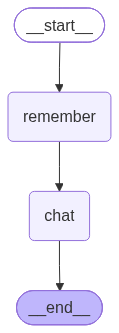

In [41]:
graph = builder.compile(store=store)
graph

In [42]:
config = {"configurable": {"user_id": "u1"}}

In [43]:
graph.invoke({"messages": [{"role": "user", "content": "Hi, my name is Saikat"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "I am learning AI Engineering as Trainee"}]}, config)

{'messages': [HumanMessage(content='I am learning AI Engineering as Trainee', additional_kwargs={}, response_metadata={}, id='a06fafc4-a5d0-483a-b9f0-183a301f94df'),
  AIMessage(content="Hi Saikat! It's awesome to see you diving into AI Engineering as a trainee—this is such a dynamic field with great opportunities to build real-world skills. Since you're starting out, I'd love to hear what specific areas you're focusing on right now (like model training, data pipelines, or cloud deployment) and whether you've tried any hands-on projects yet.  \n\n**3 relevant follow-up questions for you:**  \n1. What specific AI engineering topics are you currently exploring? (e.g., model training, data preprocessing, cloud deployment)  \n2. Have you started any small projects to apply your knowledge, like building a simple classifier or image recognition model?  \n3. What's the most challenging part of your learning process so far?  \n\nLet me know—I'm here to help you navigate the next steps! 😊", add

In [44]:
print("\n--- Stored Memories (InMemory) ---")
for it in store.search(("user", "u1", "details")):
    print("-", it.value["data"])


--- Stored Memories (InMemory) ---
- Name: Saikat
- Saikat is learning AI Engineering as a trainee.
